<a href="https://colab.research.google.com/github/Knilik97/-Pet_Project/blob/main/Pet_proect_3RL_on_Arduino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Название работы

"Умный контроллер освещения на базе Arduino и Python"

## Информация об авторе

Меня зовут Илья Вязьминский, являюсь студентом академии The founder, "инженер нейросетей" Мой дед был физиком и умел на то время ремонтировать любые силовые агригаты, понимал их суть и мог спроектировать собственный мотор для чего либо. Я пошёл в деда, но родители отдали меня в медицинский, дёскать стабильность и нужная профессия, но не понимали чего я именно хочу, да я и сам то особо не понимал. Но успешно закончив колледж, конечно я не пошёл работать по профессии, девушка, личная жизнь, работа по найму. Далее растование, путешествие и тут я вспомнил... О чём мечтал в детстве. Новые технологии, доступ в интернет, обилие информации, всё ведёт к робототехнике. Выбрав курс, я приступил к обучению, сложно ли ? ДА! но от этого интерес только вдойне. Сейчас есть цель, собрать своего робота помшника, что бы в старости рядом всегда был верный механический друг. Что нужно сделать для этой цели ? Всё просто и сложно, учиться, полгощать информацию как губка, затем воплащать в жизнь, постоянно приходя к практике.

### Краткая анатация

1-я идея: научить агента вкл/выкл светодиод с помощью фоторезистора
2-я с помощью модуля tilt switch + servo privod научить агента вкл/выкл свет или понимать если датчик наклона в вертикальном положении то свет включить, если в горизонтальном то выключить или научить агента работать с серво приводом, и всё это при условии, когда темно.

		** А если всё вместе ? **
Свет падает на фоторезистор, агент управляет серво приводом, так, что бы датчик наклона встал в горизонтально положение и контакт открылся(разомкнулся) (свет выключен), когда темно, агент приводит в действие сервопривод в вертикальное положение(контакт закрывается(замыкается) светодиод включается.

		** Оснонваня цель **
Да это довольно простой проект для технарей, но цель, получить понимание взаимодейсвия ИИ агента с физическим миром, а далее использовать это понимание для более сложных и интересных проектов.

			** Вот ключевая концепция **
когда наступает темнота(буду обучать агента методом RL) агент активирует серво-привод, к которому приклеен датчик наклона, серво привод делает поворот лопасти с датчиком наклона на 90 градусов, что приводит датчик к вертикальному положению и светодиод включается, и так же когда наступает день, агент активирует серво-привод, лопасть, с датчиком наклона делает 90 градусов в обратную сторону и датчик становиться в горизонтальное положение, светодиод отключается

#### ▌ Этапы реализации:

▌ 1. Сбор материалов и подготовка аппаратуры:

▌ Материалы:

- Arduino UNO
- Фоторезистор
- Датчик наклона (tilt-switch)
- Микро-серводвигатель (SG90)
- Светодиод (LED)
- Макетная плата и соединительные провода
- Компьютер с установленным Python и средой программирования Arduino IDE
- Чёрная изолента

▌ 2. Прошивка Arduino ▌ 3. Разработка окружения на Python ▌ 4. Моделирование окружающего мира и применение RL ▌ 5. Расширенная версия проекта с глубокой RL моделью

#### Трудности и вопросы в процессе работы

1-я При сборке схемы Ардуино, возник вопрос как поставить датчик в вертикальное положение на серво-приводе

# Скетчи Ардуино с комменатриями

При сборке нужно проверить было проверить, что всё правильно подключенно. Всё работает как часы. Вашему вниманию скетчи.

In [ ]:
# Сначала я реализовал работу фоторезистра

const int ledPin = 10;           // Подключаем Анод LED к выводу PWM D 10
const int photoresistorPin = A0; // Подключаем фоторезистор к аналоговому входу

void setup() {
  pinMode(ledPin, OUTPUT);     // Устанавливаем вывод LED как выход
}

void loop() {
  int lightLevel = analogRead(photoresistorPin);  // Читаем значение фоторезистора
  float darknessFactor = map(lightLevel, 0, 1023, 255, 0);  // Переводим показания в обратный порядок (темнее → сильнее светодиод)

  if(darknessFactor > 0 && lightLevel <= 1000){  // Проверяем условия низкой освещенности
    digitalWrite(ledPin, HIGH);                  // Включаем светодиод на полную мощность
    delay(5000);                                 // Держим светодиод включённым 5 секунд

    for(int i=255; i>=0; i--) {                   // Медленно уменьшаем яркость светодиода
      analogWrite(ledPin, i*darknessFactor/255);
      delay(10);                                  // Ожидаем ~1 секунду полного погасания
    }
  } else {
    digitalWrite(ledPin, LOW);                    // Выключаем светодиод, если среда достаточно освещённая
  }
}


In [ ]:
# Затем, подключил датчик наклона

const int ledPin = 10;           // Подключаем Анод LED к выводу PWM D10
const int photoresistorPin = A0; // Подключаем фоторезистор к аналоговому входу
const int tiltSwitchPin = 2;     // Подключаем датчик наклона к цифровому пину D2


void setup() {
  pinMode(ledPin, OUTPUT);       // Устанавливаем вывод LED как выход
  pinMode(tiltSwitchPin, INPUT_PULLUP); // Используем внутренний подтягивающий резистор
}

void loop() {
  int lightLevel = analogRead(photoresistorPin);  // Читаем значение фоторезистора
  int tiltState = digitalRead(tiltSwitchPin);     // Читаем состояние датчика наклона

  // Конвертируем уровень освещённости в коэффициент интенсивности свечения
  float darknessFactor = map(lightLevel, 0, 1023, 255, 0);  // Чем темнее, тем больше фактор

  // Основная логика работы
  if (darknessFactor > 0 && lightLevel <= 1000) {  // Если темно (уровень освещённости ≤ 1000)
    if (tiltState == LOW) {  // Горизонтальное положение датчика
      digitalWrite(ledPin, HIGH);  // Светодиод горит постоянно
    }
    else if (tiltState == HIGH) {  // Вертикальное положение датчика
      digitalWrite(ledPin, LOW);  // Светодиод сразу гаснет
    }
  }
  else {  // Если достаточно светло (lightLevel > 1000)
    digitalWrite(ledPin, LOW);  // Светодиод выключен (датчик наклона не влияет)
  }
}


In [ ]:
# Заключительный скетч, для проверки работоспособности всей системы
#include <Servo.h>  // Подключаем библиотеку для управления сервоприводом

const int ledPin = 10;           // Подключаем анод LED к выводу PWM D10
const int photoresistorPin = A0; // Подключаем фоторезистор к аналоговому входу
const int tiltSwitchPin = 2;     // Подключаем датчик наклона к цифровому пину D2
const int servoPin = 7;          // Подключаем сервопривод к пину D7

Servo myservo;                   // Объект для управления сервоприводом

void setup() {
  pinMode(ledPin, OUTPUT);       // Настройка светодиода как выхода
  pinMode(tiltSwitchPin, INPUT_PULLUP); // Используем внутренний подтягивающий резистор
  myservo.attach(servoPin);      // Подключаем сервопривод к пину
  Serial.begin(9600);            // Начало связи с ПК через последовательный порт
}

void loop() {
  // Проверяем наличие входящих сообщений
  if (Serial.available()) {
    char incomingChar = Serial.read();  // Прочитали символ

    switch(incomingChar) {
      case '0':
        myservo.write(0);               // Устанавливаем сервопривод на 0 градусов
        break;
      case '1':
        myservo.write(90);              // Устанавливаем сервопривод на 90 градусов
        break;
      default:
        break;
    }
  }

  // Измеряем уровень освещения
  int lightLevel = analogRead(photoresistorPin);

  // Отсылаем значение уровня освещенности в Python
  Serial.print("Light level: ");
  Serial.println(lightLevel);

  // Логика управления светом и двигателем
  if (lightLevel <= 900) {    // Темно
    myservo.write(0);          // Ставим двигатель вертикально
    digitalWrite(ledPin, HIGH);// Включаем свет
  } else {                     // Ярко
    myservo.write(90);         // Ставим двигатель горизонтально
    digitalWrite(ledPin, LOW); // Выключаем свет
  }

  delay(100);                 // Пауза перед следующей итерацией
}


# Приступаю к написанию агента RL и начну с установки и импорта библиотек

Но сначала пару слов. Буду писать простой Q-learning алгоритм, так как всего два действия в моей окружающей среде.

In [ ]:
# Библиотека для соедения с Arduino
!pip install pyserial -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Для работы с последовательном портом
import serial
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# === Этап 1: Определение собственной среды ===


In [ ]:
# Физическое окружение (связано с Arduino)
class LightEnvironment:
    def __init__(self, arduino_port='COM4'):
        self.ser = serial.Serial(arduino_port, baudrate=9600, timeout=1)
        self.reward_history = []

    def reliable_read(self):
        """Получает надежные данные от Arduino"""
        while True:
            response = self.ser.readline().decode('utf-8').strip()
            if ':' in response and len(response.split(':')) == 2:
                return response
            else:
                print("Игнорируем некорректный ответ:", response)

    def step(self, action):
        """Осуществляет шаг, отправляя команду на Arduino и получая показатель освещенности"""
        if action == 0:  # Горизонтальное положение (яркость высокая)
            self.ser.write(b'0')
        elif action == 1:  # Вертикальное положение (низкая освещенность)
            self.ser.write(b'1')

        # Получаем ответ от Arduino
        response = self.reliable_read()
        parts = response.split(':')
        if len(parts) != 2:
            raise ValueError("Неверный формат ответа от Arduino:", response)
        brightness = float(parts[1].strip())

        # Логика выдачи награды
        if brightness >= 900:  # Высокая освещенность
            expected_action = 0  # Желаемое действие - горизонтальное положение
        else:  # Низкая освещенность
            expected_action = 1  # Желаемое действие - вертикальное положение

        # Расчёт награды
        if abs(expected_action - action) < 0.5:
            reward = max(-brightness / 1000, -1)  # Мягкое наказание за отсутствие света
        else:
            reward = -(abs(expected_action - action) + brightness / 1000)

        self.reward_history.append(reward)
        return reward

    def reset(self):
        """Сброс истории вознаграждений"""
        self.reward_history.clear()

    def get_brightness_level(self):
        """Возвращает уровень освещенности в виде группы состояний"""
        response = self.reliable_read()
        parts = response.split(':')
        if len(parts) != 2:
            raise ValueError("Неверный формат ответа от Arduino:", response)
        brightness = float(parts[1].strip())

        # Группируем показатели освещенности в три категории
        if brightness <= 900:
            return 0  # Очень низкая освещенность
        elif brightness < 1000:
            return 1  # Умеренно низкая освещенность
        else:
            return 2  # Высокий уровень освещенности

    def plot_rewards(self):
        """Строит график накопленной награды"""
        plt.figure(figsize=(10, 6))
        plt.plot(np.cumsum(self.reward_history))
        plt.title('Накопленная награда')
        plt.xlabel('Эпизоды')
        plt.ylabel('Сумма наград')
        plt.grid(True)
        plt.show()

# === Этап 2: Реализация алгоритма Q-обучения ===

In [ ]:
# Класс агента, использующего Q-обучение
class QLearningAgent:
    def __init__(self, num_states, num_actions, alpha=0.3, gamma=0.95, epsilon=0.02):
        self.num_states = num_states
        self.num_actions = num_actions
        self.alpha = alpha  # Скорость обучения
        self.gamma = gamma  # Коэффициент дисконтирования
        self.epsilon = epsilon  # Вероятность случайного выбора
        self.Q = np.zeros((num_states, num_actions))

    def act(self, state):
        """Выбор действия (случайное или оптимальное)"""
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.num_actions)
        else:
            return np.argmax(self.Q[state])

    def learn(self, state, action, reward, next_state):
        """Обновление Q-значений на основе полученного опыта"""
        best_next_action = np.argmax(self.Q[next_state])
        td_target = reward + self.gamma * self.Q[next_state][best_next_action]
        td_error = td_target - self.Q[state][action]
        self.Q[state][action] += self.alpha * td_error

# === Этап 3: Обучение агента и построение графиков ===


In [ ]:
# Главная часть программы
if __name__ == "__main__":
    # Создаем экземпляр окружения и агента
    env = LightEnvironment()
    agent = QLearningAgent(num_states=3, num_actions=2, alpha=0.3, gamma=0.95, epsilon=0.02)

    # Параметры обучения
    num_episodes = 200  # Количество эпизодов обучения
    steps_in_episode = 50  # Максимальное количество шагов в эпизоде

    # Сборщик данных о вознаграждении
    rewards_per_episode = []

    # Основной цикл обучения
    for episode in range(num_episodes):
        total_reward = 0
        for _ in range(steps_in_episode):
            # Определение состояния (основываясь на яркости)
            state = env.get_brightness_level()
            action = agent.act(state)
            reward = env.step(action)
            agent.learn(state, action, reward, state)
            total_reward += reward

        rewards_per_episode.append(total_reward)
        avg_reward = sum(rewards_per_episode[-10:]) / min(len(rewards_per_episode), 10)
        clear_output(wait=True)
        print(f"Эпизод {episode+1}/{num_episodes}, Среднее вознаграждение за последние 10 серий: {avg_reward:.2f}")

    # Сохранение обученной Q-таблицы
    np.save("trained_q_table.npy", agent.Q)
    print("Обученная Q-таблица успешно сохранена.")

    # Рисование графика общего вознаграждения
    plt.figure(figsize=(10, 6))
    plt.plot(rewards_per_episode)
    plt.title('Награда за эпизод')
    plt.xlabel('Эпизоды')
    plt.ylabel('Суммарная награда')
    plt.grid(True)
    plt.show()

    # Закрываем соединение с Arduino
    env.close()

# Тест

In [ ]:
import serial
import numpy as np
import time
import matplotlib.pyplot as plt


# Класс среды для физического тестирования
class PhysicalTestEnvironment:
        def __init__(self, port='COM4', baud_rate=9600):
            self.ser = serial.Serial(port, baud_rate)
            self.port = port
            self.baud_rate = baud_rate
            self.episode_steps = 0
            self.total_reward = 0
            self.state = 0  # Единственный фиксированный индекс состояния
            self.reward_history = []

        def send_command(self, action):
            if action == 0:  # Горизонтальное положение (светло)
                self.ser.write(b'0')
            elif action == 1:  # Вертикальное положение (темно)
                self.ser.write(b'1')
            else:
                raise ValueError("Недопустимое действие!")

        def receive_data(self):
            # Ждем поступления данных от Arduino
            line = self.ser.readline().decode('latin-1').strip()
            if ':' not in line:
                print("Некорректный ответ:", line)
                return None
            _, brightness_str = line.split(': ', 1)
            try:
                brightness = int(brightness_str)
                return brightness
            except ValueError:
                print("Ошибка преобразования:", brightness_str)
                return None

        def calculate_reward(self, brightness, action):
            # Определяем идеальное действие на основе уровня освещённости
            ideal_action = 1 if brightness <= 900 else 0  # Вертикальное положение при низкой освещённости
            # Вычисляем награду (совпадение или расхождение с идеальным действием)
            reward = 1 if action == ideal_action else -1
            return reward

        def run_test(self, agent, steps=100):
            start_time = time.time()
            for _ in range(steps):
                # Получаем текущую освещённость
                brightness = self.receive_data()
                if brightness is None:
                    continue

                # Выбор действия агентом
                action = agent.act(self.state)
                self.send_command(action)

                # Рассчитываем награду
                reward = self.calculate_reward(brightness, action)
                self.reward_history.append(reward)
                self.total_reward += reward

            end_time = time.time()
            elapsed_time = end_time - start_time
            print(f"Время выполнения: {elapsed_time:.2f} секунд")
            print(f"Среднее вознаграждение за шаг: {np.mean(self.reward_history)}")
            print(f"Итого вознаграждение за весь тест: {self.total_reward}")

            # График полученного вознаграждения
            plt.figure(figsize=(10, 6))
            plt.plot(self.reward_history)
            plt.title('История вознаграждений агента')
            plt.xlabel('Шаг')
            plt.ylabel('Вознаграждение')
            plt.grid(True)
            plt.show()

# Класс агента (уже обученный экземпляр)
class QLearningAgent:
    def __init__(self, num_states, num_actions, q_table=None):
            self.num_states = num_states
            self.num_actions = num_actions
            self.Q = q_table  # Используется обученная Q-таблица

    def act(self, state):
            return np.argmax(self.Q[state])

# Загружаем предварительно обученную таблицу Q
Q_TABLE = np.load(r"C:\\Users\\Knilik977\\source\\repos\\Arduino_RL\\Arduino_RL\\trained_q_table.npy")  # Файл с обученной Q-таблицей

# Создание экземпляра агента
agent = QLearningAgent(num_states=1, num_actions=2, q_table=Q_TABLE)

# Создаем физическую среду для тестирования
physical_env = PhysicalTestEnvironment('COM4')  # Укажите правильный COM-порт

# Начинаем тестовый прогон
physical_env.run_test(agent, steps=100)

# Вывод

*Какие трудности возникли в процессе написания проекта:*
- соединение python and Arduino: трудность в передаче корректных* данных, из-за обилие шума, агент не понимал данные из-за чего обучение сводилось в максимальное награждение минус -1.40, после того как произведенна отладка кода и вызов исключений, стало понятно куда идти
- агент обучается слишком хорошо, что видно на скриншотах, трудность возникла из-за непонимания vscode, бонально ? да. Но привыкший писать в PyCharme, пришлось учится писать в vscode.
- трудности провести тесты, т.к. скетч ардуино загружен на плату я не понимал, как рабоатет агент, но все же написав код-тест, удалось провести оценку

Решения:

- не много нерв и терпения, получилось наладить корректное обучение
- наладил тест показывает не плохое вознагрождение


Подкрепляю фото, скриншоты, видео

# Компоненты ардуино

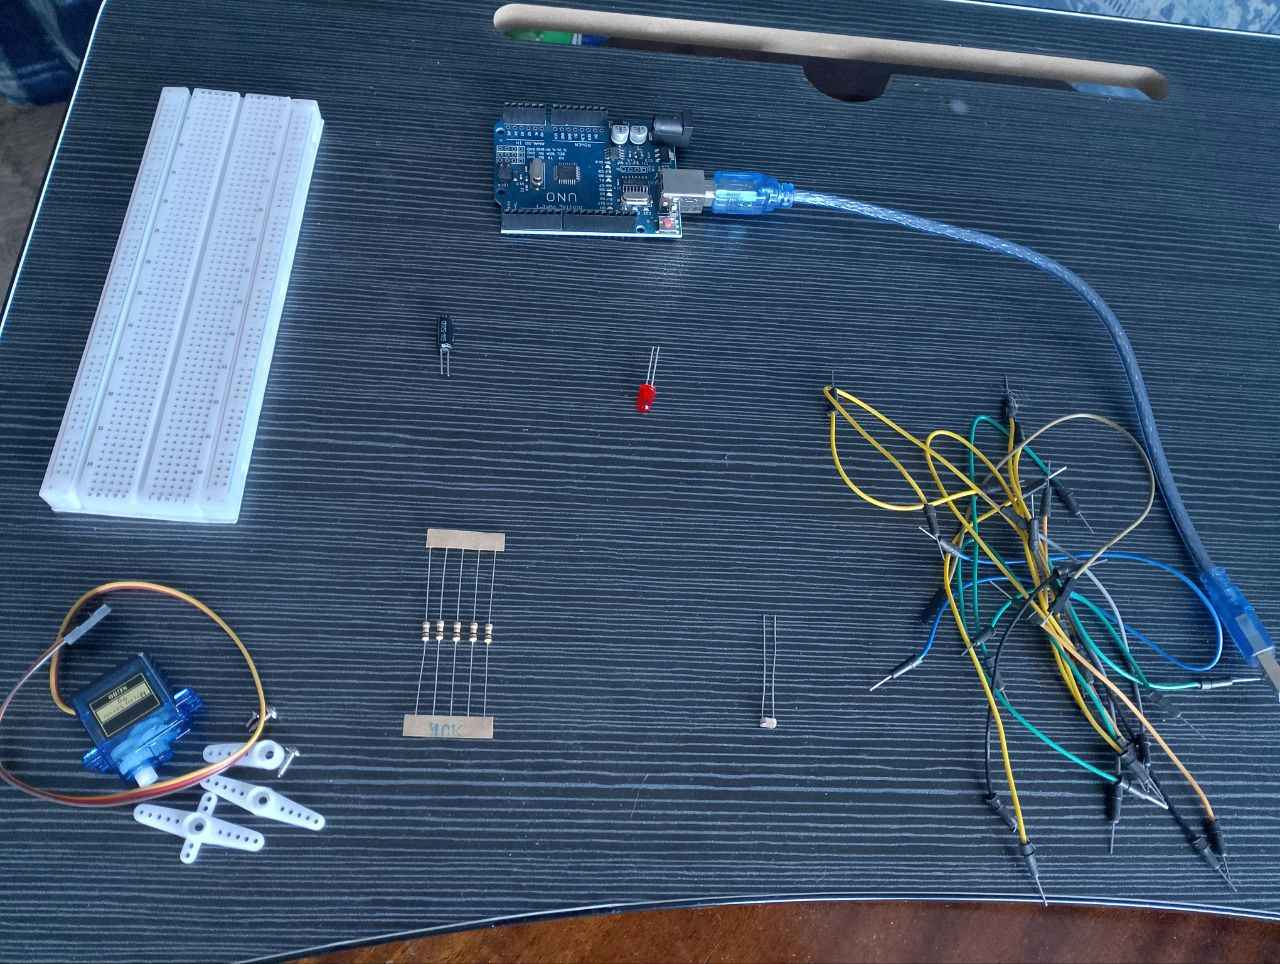

# Собранная схема ардуино

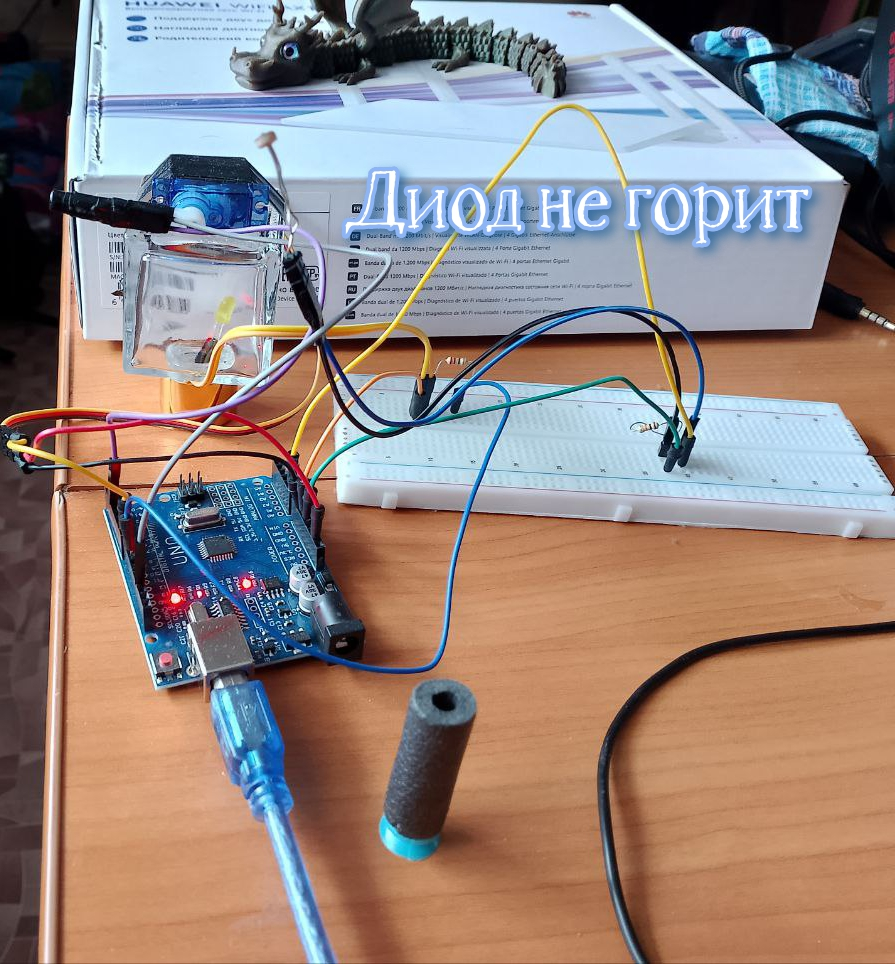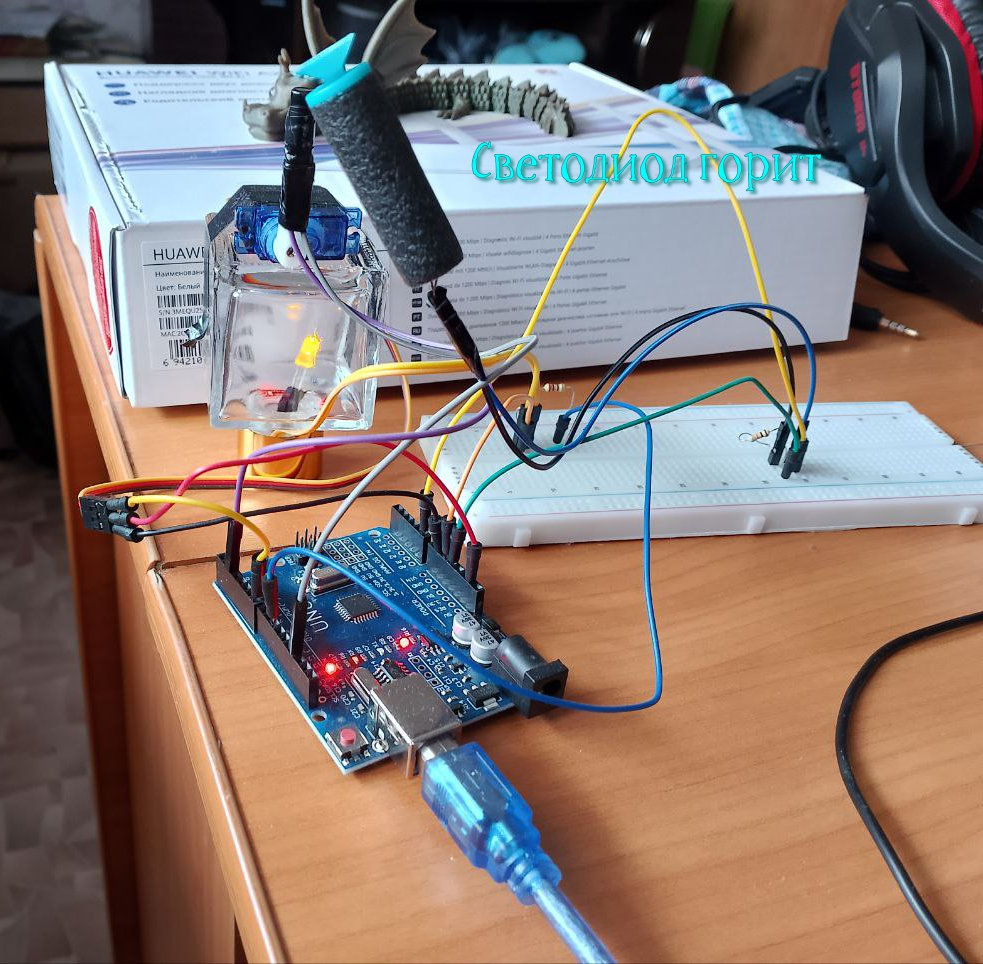

#Скриншоты

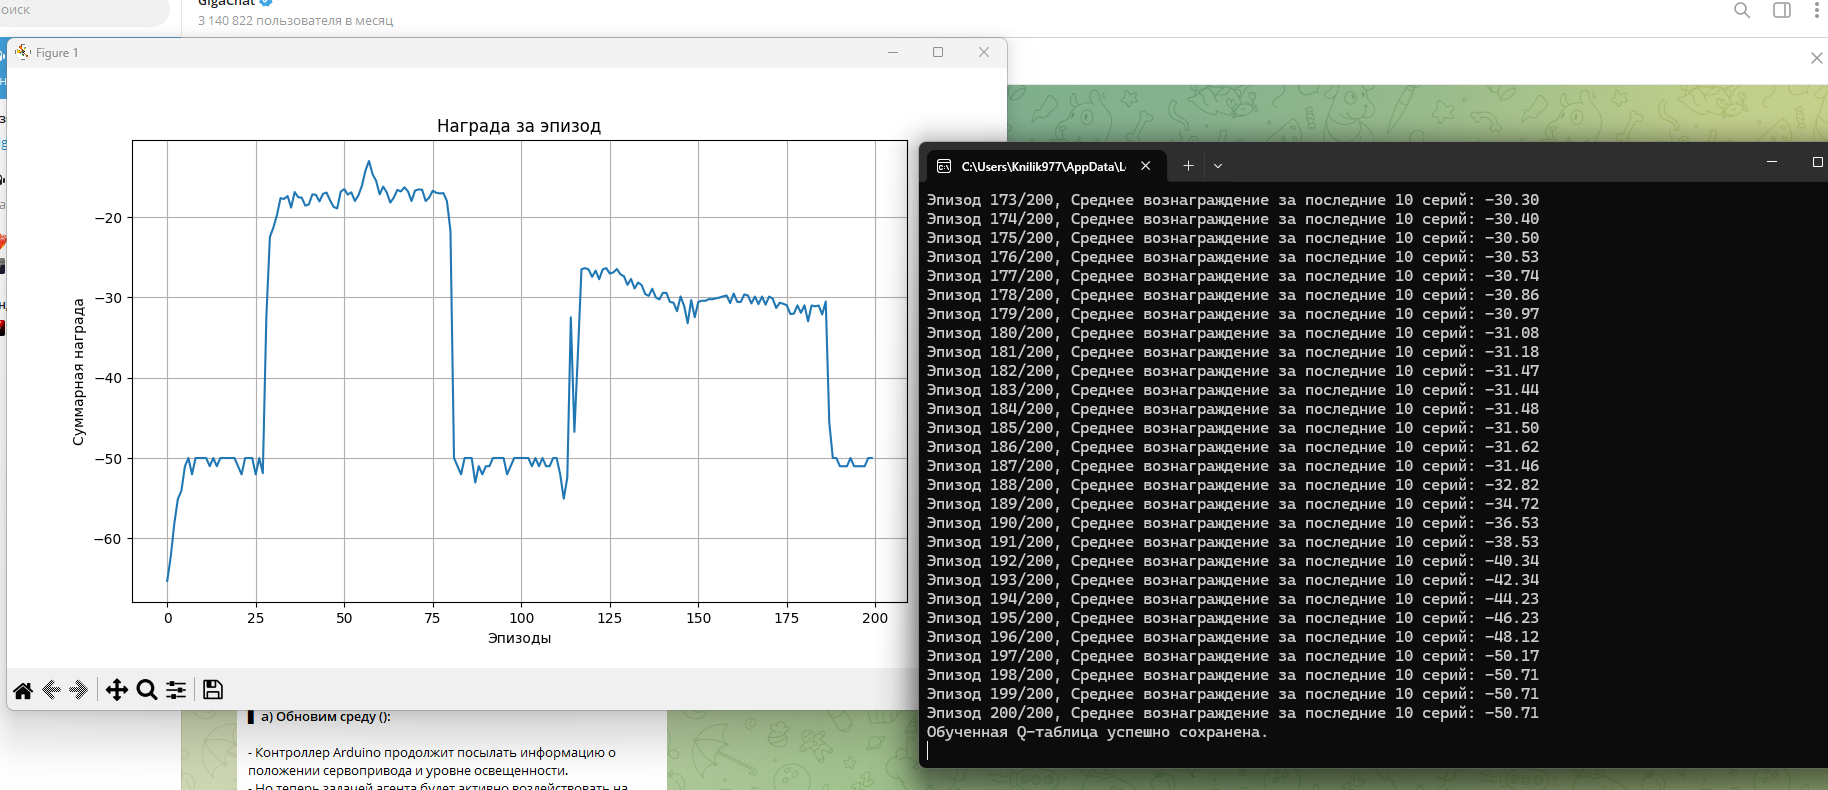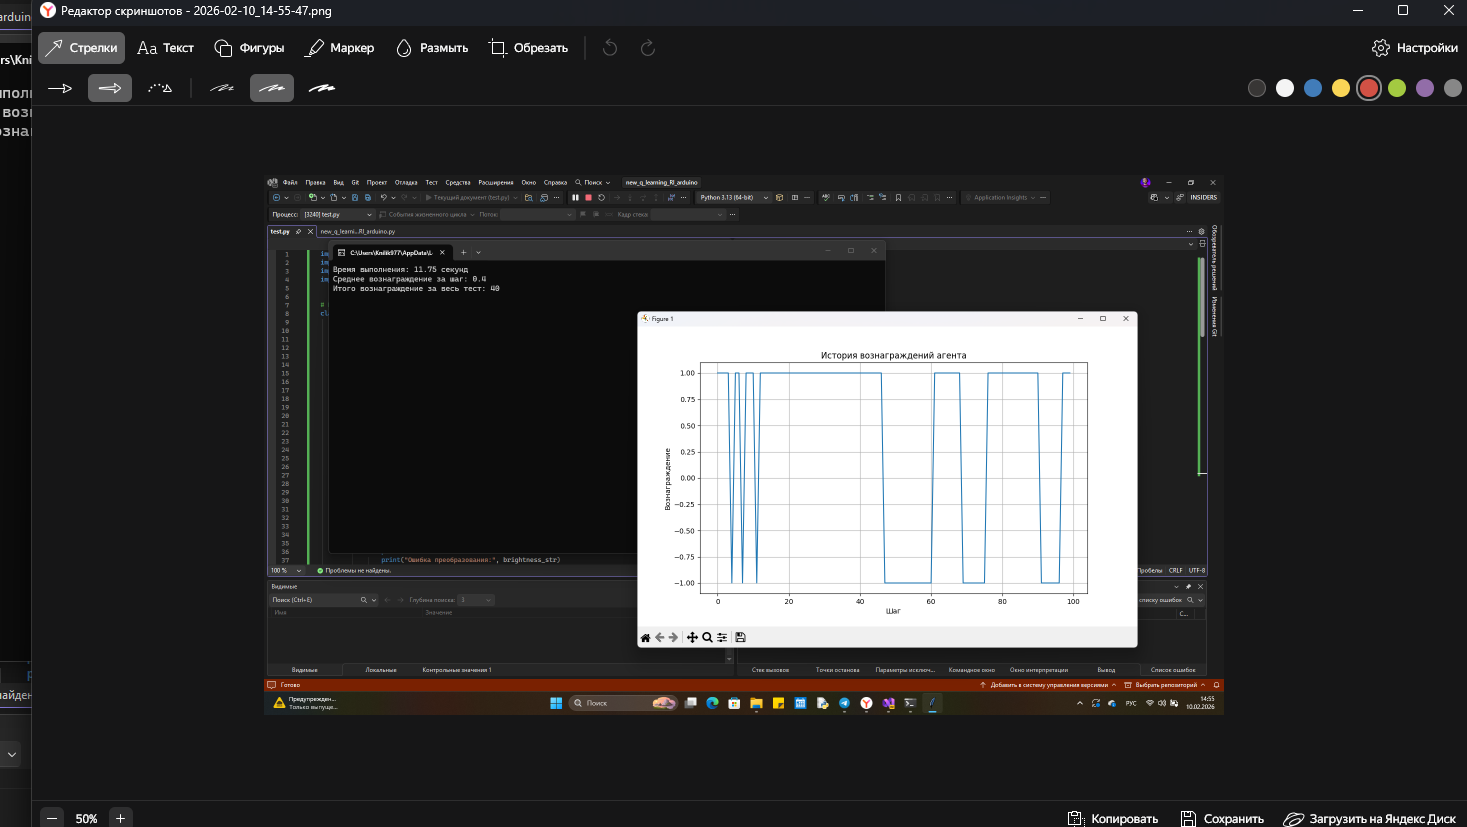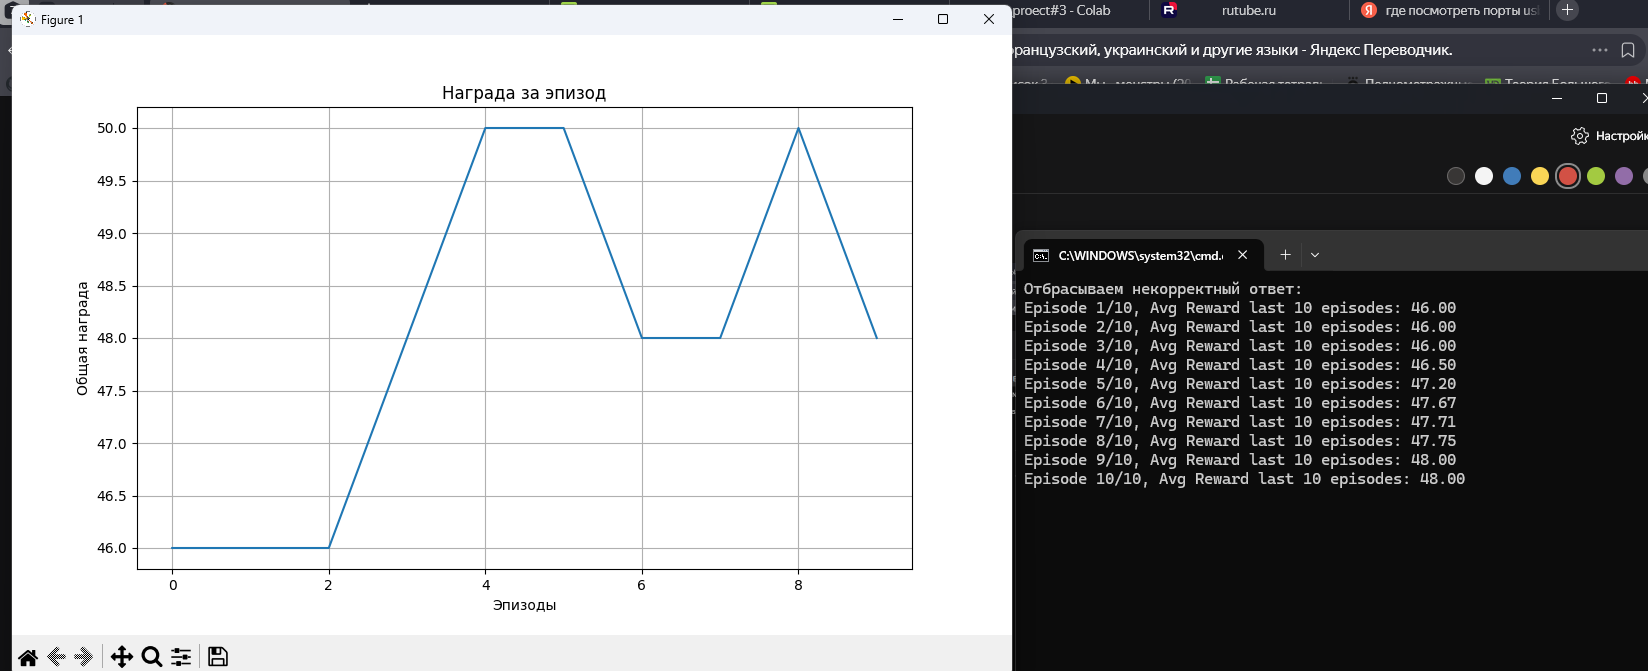

# Желательно реализиовать тест с физ средой независимо от скетча

# Ссылка на видео

https://disk.yandex.ru/i/zulxokU6zodP-A

# Следующая идея заключатеся в жёстком условии при создании среды для агента условия

Вместо пассивного реагирования на текущую освещенность (как было раньше), теперь задача агента станет активной: он должен самостоятельно регулировать положение сервопривода, включая или выключая светодиод в зависимости от внешнего воздействия.



# Дополнение проекта

Так же в доаолнение проекта я добавил обучение в два этапа:
- светлая среда
- тёмная среда

Так же код запускался в "vscode", скриншоты прилагаю


## Основные изменения:

Правильное обновление состояния: Добавлена правильная передача текущего и следующего состояний в метод learn.

Исправленный цикл обучения: Теперь агент получает следующее состояние после каждого действия и использует его для обучения.

In [ ]:
import numpy as np
import serial
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Физическое окружение (связано с Arduino)
class LightEnvironment:
    def __init__(self, arduino_port='COM4'):
        self.ser = serial.Serial(arduino_port, baudrate=9600, timeout=1)
        self.reward_history = []

    def reliable_read(self):
        """Получает надежные данные от Arduino"""
        while True:
            response = self.ser.readline().decode('utf-8').strip()
            if ':' in response and len(response.split(':')) == 2:
                return response
            else:
                print("Игнорируем некорректный ответ:", response)

    def step(self, action):
        """Осуществляет шаг, отправляя команду на Arduino и получая показатель освещенности"""
        if action == 0:  # Горизонтальное положение (яркость высокая)
            self.ser.write(b'0')
        elif action == 1:  # Вертикальное положение (низкая освещенность)
            self.ser.write(b'1')

        # Получаем ответ от Arduino
        response = self.reliable_read()
        parts = response.split(':')
        if len(parts) != 2:
            raise ValueError("Неверный формат ответа от Arduino:", response)
        brightness = float(parts[1].strip())

        # Логика выдачи награды
        if brightness >= 900:  # Высокая освещенность
            expected_action = 0  # Желаемое действие - горизонтальное положение
        else:  # Низкая освещенность
            expected_action = 1  # Желаемое действие - вертикальное положение

        # Упрощённая система вознаграждения
        if abs(expected_action - action) < 0.5:
            reward = 1  # Положительная награда за правильное действие
        else:
            reward = -1  # Отрицательная награда за неправильное действие

        self.reward_history.append(reward)
        return reward

    def reset(self):
        """Сброс истории вознаграждений"""
        self.reward_history.clear()

    def get_brightness_level(self):
        """Возвращает уровень освещенности в виде группы состояний"""
        response = self.reliable_read()
        parts = response.split(':')
        if len(parts) != 2:
            raise ValueError("Неверный формат ответа от Arduino:", response)
        brightness = float(parts[1].strip())

        # Границы для группировки
        if brightness <= 860:
            return 0  # Темно
        elif brightness <= 1020:
            return 1  # Средний уровень освещенности
        else:
            return 2  # Яркий свет

    def plot_rewards(self):
        """Строит график накопленной награды"""
        plt.figure(figsize=(10, 6))
        plt.plot(np.cumsum(self.reward_history))
        plt.title('Накопленная награда')
        plt.xlabel('Эпизоды')
        plt.ylabel('Сумма наград')
        plt.grid(True)
        plt.show()

# Класс агента, использующего Q-обучение
class QLearningAgent:
    def __init__(self, num_states, num_actions, alpha=0.3, gamma=0.95, epsilon=0.02):
        self.num_states = num_states
        self.num_actions = num_actions
        self.alpha = alpha  # Скорость обучения
        self.gamma = gamma  # Коэффициент дисконтирования
        self.epsilon = epsilon  # Вероятность случайного выбора
        self.Q = np.zeros((num_states, num_actions))

    def act(self, state):
        """Выбор действия (случайное или оптимальное)"""
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.num_actions)
        else:
            return np.argmax(self.Q[state])

    def learn(self, state, action, reward, next_state):
        """Обновление Q-значений на основе полученного опыта"""
        best_next_action = np.argmax(self.Q[next_state])
        td_target = reward + self.gamma * self.Q[next_state][best_next_action]
        td_error = td_target - self.Q[state][action]
        self.Q[state][action] += self.alpha * td_error

# Главная часть программы
if __name__ == "__main__":
    # Создаем экземпляр окружения и агента
    env = LightEnvironment()
    agent = QLearningAgent(num_states=3, num_actions=2, alpha=0.3, gamma=0.95, epsilon=0.02)

    # Параметры обучения
    first_stage_episodes = 10  # Первая фаза обучения (яркий свет)
    second_stage_episodes = 10  # Вторая фаза обучения (темнота)
    steps_in_episode = 10  # Максимальное количество шагов в эпизоде

    # Массивы для записи историй вознаграждений
    bright_rewards = []
    dark_rewards = []

    # Этап 1: Обучение в яркой среде
    print("\n--- НАЧАЛО ПЕРВОЙ ФАЗЫ ОБУЧЕНИЯ ---")
    for episode in range(first_stage_episodes):
        total_reward = 0
        current_state = env.get_brightness_level()

        for _ in range(steps_in_episode):
            action = agent.act(current_state)
            reward = env.step(action)
            next_state = env.get_brightness_level()

            # Обучение агента
            agent.learn(current_state, action, reward, next_state)

            # Подготовка к следующему шагу
            current_state = next_state
            total_reward += reward

        bright_rewards.append(total_reward)
        avg_reward = sum(bright_rewards[-10:]) / min(len(bright_rewards), 10)
        clear_output(wait=True)
        print(f"Первая фаза. Эпизод {episode+1}/{first_stage_episodes}, средняя награда: {avg_reward:.2f}")

    # Этап 2: Обучение в темной среде
    print("\n--- НАЧАЛО ВТОРОЙ ФАЗЫ ОБУЧЕНИЯ ---")
    for episode in range(second_stage_episodes):
        total_reward = 0
        current_state = env.get_brightness_level()

        for _ in range(steps_in_episode):
            action = agent.act(current_state)
            reward = env.step(action)
            next_state = env.get_brightness_level()

            # Обучение агента
            agent.learn(current_state, action, reward, next_state)

            # Подготовка к следующему шагу
            current_state = next_state
            total_reward += reward

        dark_rewards.append(total_reward)
        avg_reward = sum(dark_rewards[-10:]) / min(len(dark_rewards), 10)
        clear_output(wait=True)
        print(f"Вторая фаза. Эпизод {episode+1}/{second_stage_episodes}, средняя награда: {avg_reward:.2f}")

    # Сохранение обученной Q-таблицы
    np.save("trained_q_table.npy", agent.Q)
    print("Обученная Q-таблица успешно сохранена.")

    # Графики для обеих фаз обучения
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 1, 1)
    plt.plot(bright_rewards)
    plt.title('Первая фаза (яркий свет)')
    plt.xlabel('Эпизоды')
    plt.ylabel('Суммарная награда')
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(dark_rewards)
    plt.title('Вторая фаза (темнота)')
    plt.xlabel('Эпизоды')
    plt.ylabel('Суммарная награда')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Закрываем соединение с Arduino
    env.close()

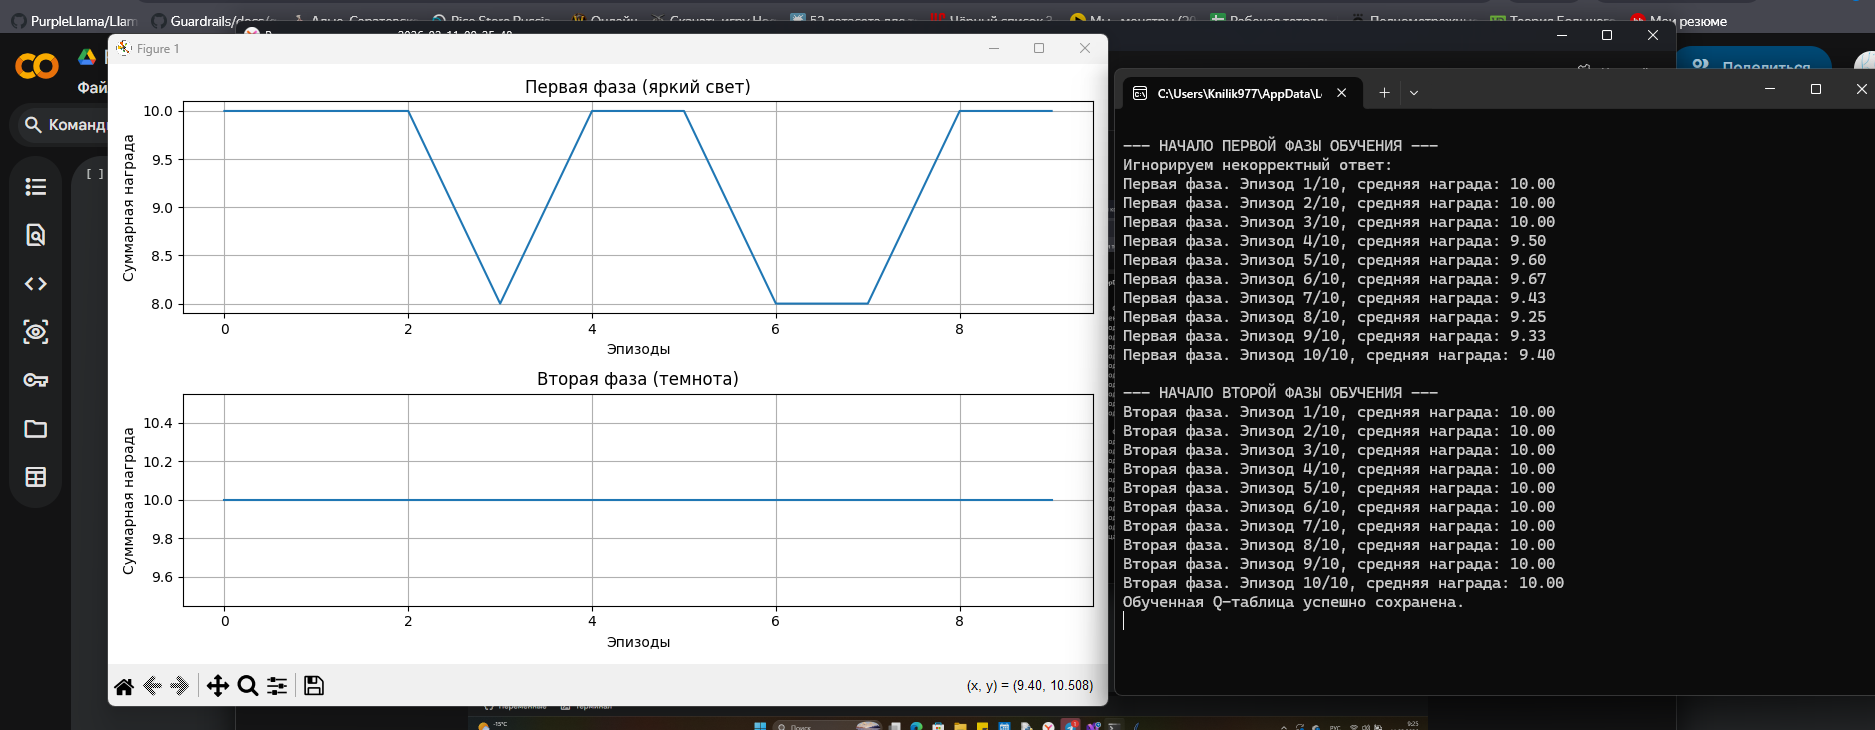

# Первый тест после двух фаз обучений

Наконец-то получилось наладить достоверную связь с арудино без влияния скета

На скрине видно, что Освещённость меняется, состояние меняется но агент не принимает ни каких дейсвий на изменение окружающих факторов

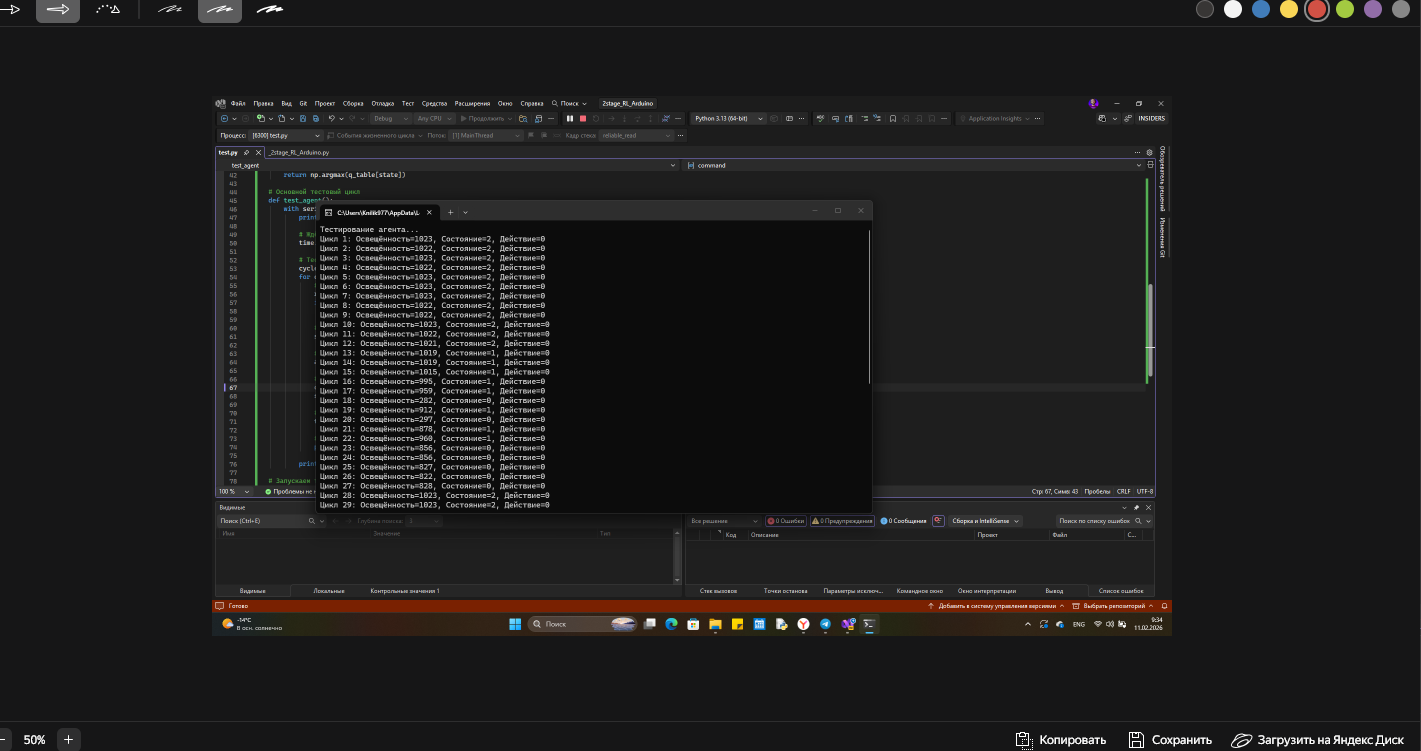

# Ну и последний код

Ключевые улучшения:
Расширенное пространство состояний:

Количество состояний увеличилось с трех до пяти (очень темно → средне-темно → среднее освещение → светло → очень светло). Это помогает агенту точнее оценивать ситуацию и подбирать подходящие действия.
Переработанная система вознаграждений:

Новый подход к назначению наград основан на сравнении желаемого действия с фактически выбранным действием. Плюсовыми становятся действия, соответствующие условиям освещённости, а минусовые используются для коррекции ошибок.
Настройка гиперпараметров:

Значения были скорректированы таким образом, чтобы ускорить процесс обучения и обеспечить баланс между исследованием и использованием лучших известных действий.
Более продолжительное обучение:

Увеличен общий объём тренировочных эпизодов и продолжительность отдельных эпизодов. Это даёт агенту больше возможностей для изучения и подбора оптимальной стратегии.

In [ ]:
import numpy as np
import serial
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Физическое окружение (связано с Arduino)
class LightEnvironment:
    def __init__(self, arduino_port='COM4'):
        """
        Инициализирует объект класса LightEnvironment, устанавливая соединение с Arduino.
        """
        self.ser = serial.Serial(arduino_port, baudrate=9600, timeout=1)
        self.reward_history = []  # История вознаграждений

    def reliable_read(self):
        """
        Надежно читает строку данных с Arduino, игнорируя некорректные ответы.
        """
        while True:
            response = self.ser.readline().decode('utf-8').strip()
            if ':' in response and len(response.split(':')) == 2:
                return response
            else:
                print("Игнорируем некорректный ответ:", response)

    def step(self, action):
        """
        Выполняет шаг, отправляя команду на Arduino и возвращая вознаграждение.
        Новая схема награждения:
          - За правильное действие получаем +1.
          - За неправильное действие штрафуется небольшой отрицательной наградой (-0.5).
        """
        if action == 0:  # Горизонтальное положение (желательно при высоком свете)
            self.ser.write(b'0')
        elif action == 1:  # Вертикальное положение (предпочтительно при низком свете)
            self.ser.write(b'1')

        # Получаем отклик от Arduino
        response = self.reliable_read()
        parts = response.split(':')
        if len(parts) != 2:
            raise ValueError("Ошибка формата отклика от Arduino:", response)
        brightness = float(parts[1].strip())

        # Новое правило назначения награды
        if brightness > 900:  # Высокий свет
            expected_action = 0  # Оптимально держать горизонтально
        else:                  # Нехватка света
            expected_action = 1  # Лучше повернуть вертикально

        # Назначение награды
        if abs(expected_action - action) < 0.5:
            reward = 1  # Правильное действие
        else:
            reward = -0.5  # Неправильное действие

        self.reward_history.append(reward)
        return reward

    def reset(self):
        """
        Сбрасывает историю вознаграждений перед новым этапом.
        """
        self.reward_history.clear()

    def get_brightness_level(self):
        """
        Возвращает индекс состояния освещённости (новый расширенный диапазон состояний).
        Теперь используется пять диапазонов освещённости для лучшего распознавания ситуаций.
        """
        response = self.reliable_read()
        parts = response.split(':')
        if len(parts) != 2:
            raise ValueError("Ошибка формата отклика от Arduino:", response)
        brightness = float(parts[1].strip())

        # Разделение освещённости на пять категорий:
        if brightness <= 500:
            return 0  # Очень темно
        elif brightness <= 700:
            return 1  # Средне-темно
        elif brightness <= 900:
            return 2  # Средняя освещённость
        elif brightness <= 1100:
            return 3  # Светло
        else:
            return 4  # Очень светло

    def plot_rewards(self):
        """
        Строит график накопления общей награды за все эпизоды.
        """
        plt.figure(figsize=(10, 6))
        plt.plot(np.cumsum(self.reward_history))
        plt.title('Накопленная награда')
        plt.xlabel('Эпизоды')
        plt.ylabel('Сумма наград')
        plt.grid(True)
        plt.show()

# Класс агента, использующего Q-обучение
class QLearningAgent:
    def __init__(self, num_states, num_actions, alpha=0.5, gamma=0.9, epsilon=0.2):
        """
        Инициализирует агента с новыми настройками гиперпараметров:
          - alpha (скорость обучения) повышена до 0.5 для ускорения обучения.
          - gamma (коэффициент дисконтирования) немного снижен до 0.9.
          - epsilon (вероятность случайного выбора) увеличено до 0.2 для лучшей разведки.
        """
        self.num_states = num_states
        self.num_actions = num_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.Q = np.zeros((num_states, num_actions))  # Таблица Q-матрицы

    def act(self, state):
        """
        Метод для выбора действия (использует стратегию Epsilon-greedy).
        """
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.num_actions)  # Случайное действие
        else:
            return np.argmax(self.Q[state])           # Лучшее известное действие

    def learn(self, state, action, reward, next_state):
        """
        Обновляет Q-таблицу на основе полученной награды и нового состояния.
        Используется стандартный алгоритм обновления Q-обучения.
        """
        best_next_action = np.argmax(self.Q[next_state])
        td_target = reward + self.gamma * self.Q[next_state][best_next_action]
        td_error = td_target - self.Q[state][action]
        self.Q[state][action] += self.alpha * td_error


# Основная программа
if __name__ == "__main__":
    # Создание экземпляра окружения и агента
    env = LightEnvironment()
    agent = QLearningAgent(num_states=5, num_actions=2, alpha=0.5, gamma=0.9, epsilon=0.2)

    # Параметры обучения
    first_stage_episodes = 100  # Увеличили число эпизодов первой фазы
    second_stage_episodes = 100  # Увеличили число эпизодов второй фазы
    steps_in_episode = 100       # Увеличили максимальное количество шагов в эпизоде

    # Массивы для хранения истории вознаграждений
    bright_rewards = []
    dark_rewards = []

    # Первая фаза обучения (яркий свет)
    print("\n--- НАЧАЛО ПЕРВОЙ ФАЗЫ ОБУЧЕНИЯ ---")
    for episode in range(first_stage_episodes):
        total_reward = 0
        current_state = env.get_brightness_level()

        for _ in range(steps_in_episode):
            action = agent.act(current_state)
            reward = env.step(action)
            next_state = env.get_brightness_level()

            # Обучение агента
            agent.learn(current_state, action, reward, next_state)

            # Подготовка к следующему шагу
            current_state = next_state
            total_reward += reward

        bright_rewards.append(total_reward)
        avg_reward = sum(bright_rewards[-10:]) / min(len(bright_rewards), 10)
        clear_output(wait=True)
        print(f"Первая фаза. Эпизод {episode+1}/{first_stage_episodes}, средняя награда: {avg_reward:.2f}")

    # Вторая фаза обучения (темнота)
    print("\n--- НАЧАЛО ВТОРОЙ ФАЗЫ ОБУЧЕНИЯ ---")
    for episode in range(second_stage_episodes):
        total_reward = 0
        current_state = env.get_brightness_level()

        for _ in range(steps_in_episode):
            action = agent.act(current_state)
            reward = env.step(action)
            next_state = env.get_brightness_level()

            # Обучение агента
            agent.learn(current_state, action, reward, next_state)

            # Подготовка к следующему шагу
            current_state = next_state
            total_reward += reward

        dark_rewards.append(total_reward)
        avg_reward = sum(dark_rewards[-10:]) / min(len(dark_rewards), 10)
        clear_output(wait=True)
        print(f"Вторая фаза. Эпизод {episode+1}/{second_stage_episodes}, средняя награда: {avg_reward:.2f}")

    # Сохраняем обученную Q-таблицу
    np.save("trained_q_table.npy", agent.Q)
    print("Обученная Q-таблица успешно сохранена.")

    # Построение графиков вознаграждений
    plt.figure(figsize=(10, 6))
    plt.subplot(2, 1, 1)
    plt.plot(bright_rewards)
    plt.title('Первая фаза (яркий свет)')
    plt.xlabel('Эпизоды')
    plt.ylabel('Суммарная награда')
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(dark_rewards)
    plt.title('Вторая фаза (темнота)')
    plt.xlabel('Эпизоды')
    plt.ylabel('Суммарная награда')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Завершение соединения с Arduino
    env.close()


# Окончательный вывод

В целом я считаю область роботехники увлекательным, сложным, но позновательной областью, понимание того как эта область может изменить наш миру и помочь людям, в особенности старикам*(одиноким), даёт сильную мотивацию изучать эту область.

Не смотря на возникашие сложности, конечно не хватка знаний по физике, электродинамике(заполняю пробелы в процесее) всё же удалось добиться результатов, пускай скромных, но это только начало.

**Основые выводы о процессе работы я написал выше**

Следующим этапом можно сделать: Вместо пассивного реагирования на текущую освещенность (как было раньше), теперь задача агента станет активной: он должен самостоятельно регулировать положение сервопривода, включая или выключая светодиод в зависимости от внешнего воздействия.

Но на этот проект я потратил кучу времени, поэтому не в этот раз.

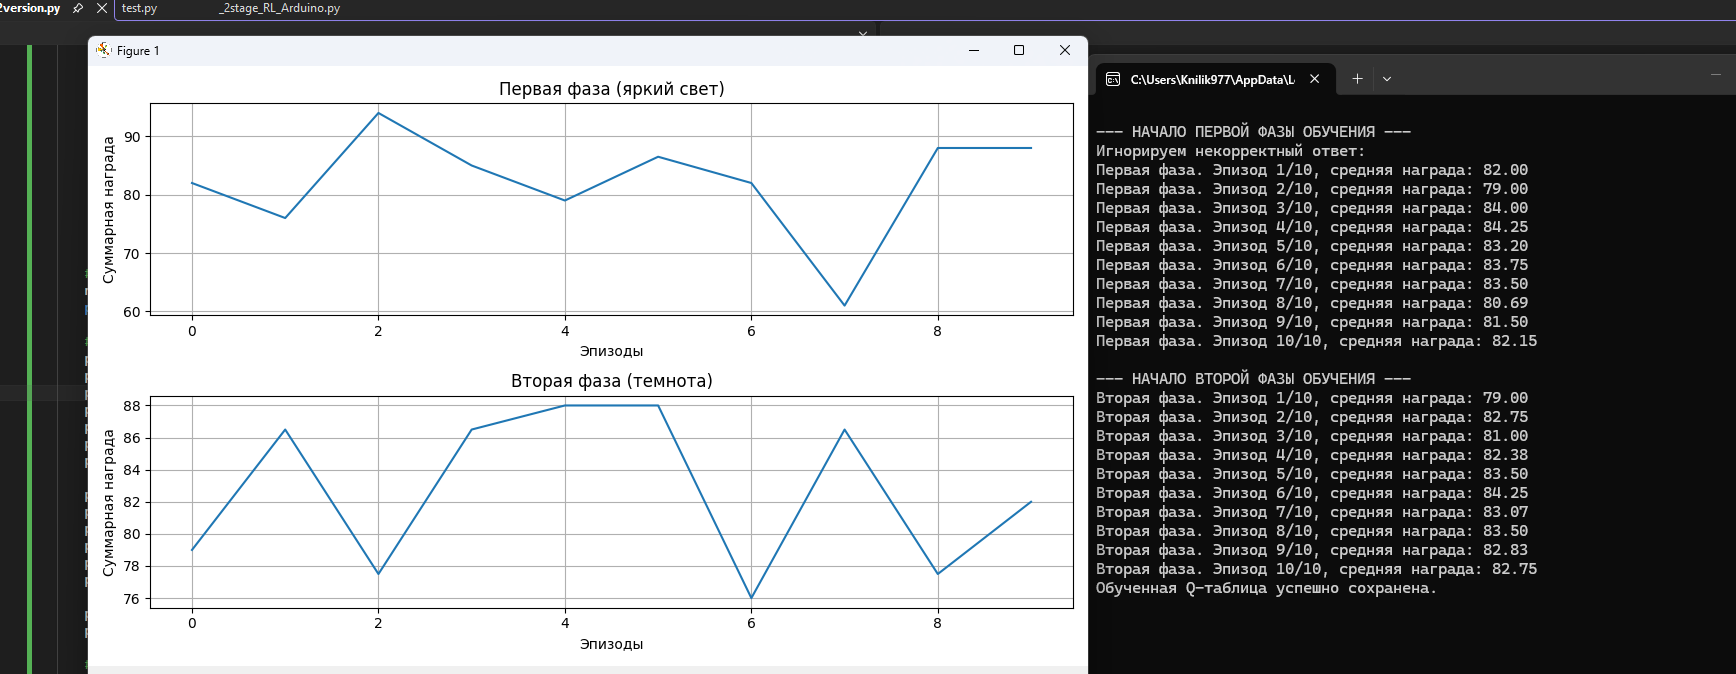

# Заключительный тест успешенен, проект выполнен.

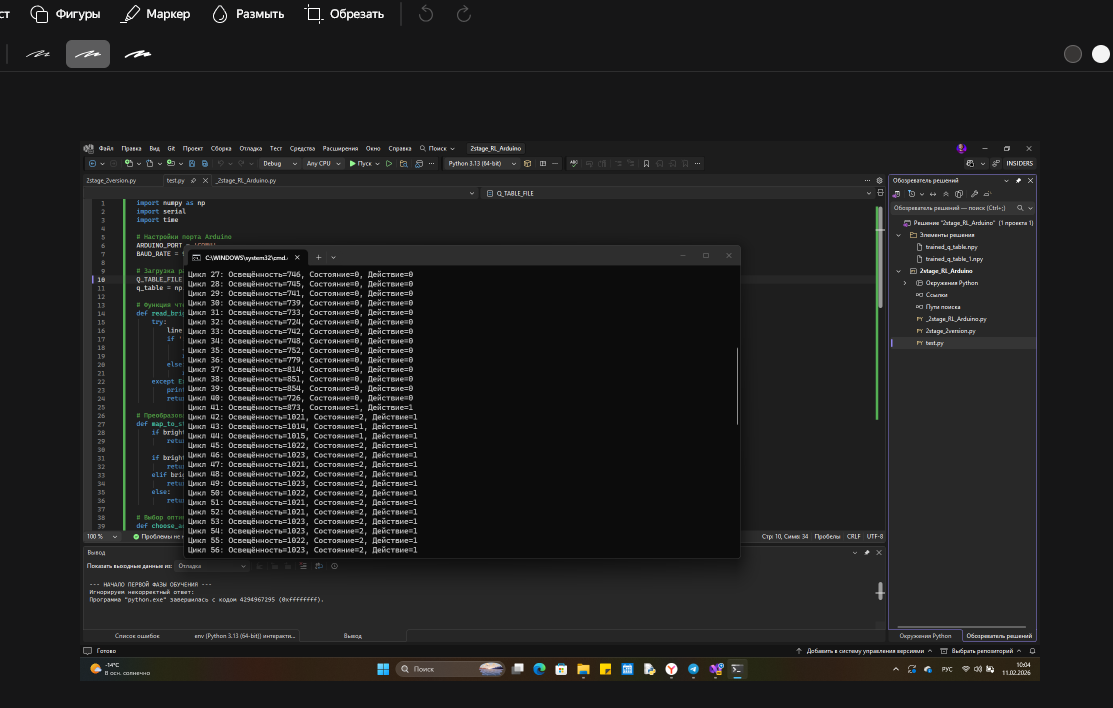